#**Summary**

This notebook performs the final, out-of-sample evaluation of the three sparse index-tracking methods developed in Notebook 02. The out-of-sample period (2023-02-03 to 2026-01-02, 39 monthly rebalances) was held out during all methodology calibration and is used here for an unbiased assessment. The backtest framework, configuration, and all three fit functions are redefined so that the notebook runs independently, and the in-sample results from Notebook 02 are loaded for direct comparison. The analysis covers the out-of-sample backtest, a transaction-cost sensitivity study, and five visualizations.

**Efficient cost analysis.** The walk-forward engine is modified to return gross returns and per-rebalance turnover separately, rather than subtracting a fixed cost internally. This lets a single expensive backtest run support the entire transaction-cost sensitivity study across 0, 5, 10, and 20 bps, avoiding four separate runs of the slow SLAIT solver. Each cost level is applied to the gross returns afterward via a lightweight helper.

**Out-of-sample backtest.** The three methods were run once per cardinality on the out-of-sample rebalances, taking about 37 minutes in total, dominated by SLAIT. As in-sample, LASSO at K=100 was infeasible under non-negativity. Gross returns, turnover, and weights were persisted to Google Drive so the run never needs repeating.

**Tracking generalizes.** The central methodological result is that out-of-sample tracking error closely matches the in-sample value for every method and cardinality, with most differences below half a percentage point. For example, top-K at K=100 moves from 3.44% to 3.39%, LASSO at K=50 from 5.06% to 5.00%, and SLAIT at K=50 from 4.20% to 4.41%. The rolling refit adapts to each new period, so tracking quality is preserved despite the out-of-sample regime — the 2023 banking stress and the 2023-2024 rally — differing sharply from the calibration years. The method ordering is also preserved: SLAIT is the tightest tracker at each shared cardinality in both periods.

**Transaction costs are decisive.** Turnover differs by an order of magnitude across methods: top-K turns over about 80-106% annually, while LASSO and SLAIT turn over 1244-1616%. As a result, net return erodes far faster for the optimizers — losing roughly 2.7 to 3.9 percentage points as cost rises from 0 to 20 bps, versus about 0.35 points for top-K. At K=50, both LASSO and SLAIT begin above the benchmark at zero cost but fall below it at realistic cost levels, crossing around 8 bps. The apparent advantage of the optimizers disappears once trading frictions are accounted for.

**Outperformance is not tracking skill.** Over this rally-dominated period, most portfolios beat the benchmark — top-K at K=10 returned 42% against the benchmark's 21% — but this reflects favorable deviation, not replication quality. Top-K carries the highest tracking error of all methods at each cardinality; its strong returns and high Sharpe ratios are a realized consequence of its mega-cap tilt. The portfolios that genuinely replicate the index in both risk and return are SLAIT and LASSO at higher cardinality, which sit closest to the benchmark in risk-return space.

**Persisted artifacts.** The out-of-sample gross returns, per-rebalance turnover, rebalance weights, and the full performance table across all cost levels are saved to Google Drive in Parquet format. A JSON manifest records the configuration and artifact contents, completing a consistent, self-describing set of files across the three notebooks of the project.

#Imports and Setup

This block installs and imports all libraries used in the notebook, and mounts Google Drive. The setup mirrors Notebook 02 exactly, since this notebook reuses the same backtest framework and methods. The configuration constants, point-in-time universe filter, performance metrics, walk-forward engine, and all three fit functions are redefined here so that this notebook is self-contained and can be run independently.

**Libraries and Environment**

The notebook uses the same scientific Python stack as Notebook 02: NumPy and pandas for data handling, CVXPY for the LASSO optimization, rpy2 for the SLAIT R package, and matplotlib with seaborn for visualization. The R package `sparseIndexTracking` is loaded at session start. The random seed is fixed at 100 for reproducibility.

In [1]:
!pip install yfinance --quiet
!pip install cvxpy --quiet


import os
import re
import time
import warnings
from io import StringIO
import json

import numpy as np
import pandas as pd
import requests
import yfinance as yf
import cvxpy as cp
from scipy.optimize import brentq

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from tqdm.auto import tqdm


# rpy2 setup
import rpy2.robjects as ro
import rpy2.rinterface_lib.callbacks
from rpy2.robjects import numpy2ri, pandas2ri

numpy2ri.activate()
pandas2ri.activate()

# Suppress R console output
rpy2.rinterface_lib.callbacks.consolewrite_print = lambda x: None
rpy2.rinterface_lib.callbacks.consolewrite_warnerror = lambda x: None

# Install the R package sparseIndexTracking if not already present
ro.r('''
suppressPackageStartupMessages(suppressMessages(suppressWarnings({
    if (!require("sparseIndexTracking", quietly = TRUE)) {
        install.packages("sparseIndexTracking", repos = "http://cran.r-project.org", quiet = TRUE)
    }
    library(sparseIndexTracking)
})))
''')


# Drive mount and paths
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

PROJECT_DIR = '/content/drive/MyDrive/ml_finance_project_index_tracking'
CACHE_DIR = f'{PROJECT_DIR}/cache_modeling'
os.makedirs(CACHE_DIR, exist_ok=True)


# Reproducibility
SEED = 100
np.random.seed(SEED)


# Display settings
from google.colab import data_table
data_table.disable_dataframe_formatter()

plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

warnings.filterwarnings('ignore')


# Version info
print(f"numpy:       {np.__version__}")
print(f"pandas:      {pd.__version__}")
print(f"yfinance:    {yf.__version__}")
print(f"cvxpy:       {cp.__version__}")
print(f"PROJECT_DIR: {PROJECT_DIR}")
print(f"CACHE_DIR:   {CACHE_DIR}")

Mounted at /content/drive
numpy:       2.0.2
pandas:      2.2.2
yfinance:    0.2.66
cvxpy:       1.6.7
PROJECT_DIR: /content/drive/MyDrive/ml_finance_project_index_tracking
CACHE_DIR:   /content/drive/MyDrive/ml_finance_project_index_tracking/cache_modeling


#Data Loading

This section loads two groups of artifacts: the model-ready weekly returns produced in Notebook 01, and the in-sample backtest results saved in Notebook 02. The in-sample results are retained for the in-sample versus out-of-sample comparison later in this notebook. The configuration manifest from Notebook 02 is also loaded to verify that the framework parameters match.

In [6]:
# Load model-ready data from Notebook 01 (stored directly in PROJECT_DIR)
returns_weekly = pd.read_parquet(f'{PROJECT_DIR}/returns_weekly.parquet')
index_returns_weekly = pd.read_parquet(f'{PROJECT_DIR}/index_returns_weekly.parquet')
if isinstance(index_returns_weekly, pd.DataFrame):
    index_returns_weekly = index_returns_weekly.iloc[:, 0]

constituents = pd.read_parquet(f'{PROJECT_DIR}/constituents.parquet')
prices_daily = pd.read_parquet(f'{PROJECT_DIR}/prices_daily_raw.parquet')

# Load universe filter (one ticker per line)
with open(f'{PROJECT_DIR}/universe_filtered.txt') as f:
    universe_filtered = [line.strip() for line in f if line.strip()]

# Load auxiliary shares-outstanding cache (used by top-K)
shares_df = pd.read_parquet(f'{CACHE_DIR}/shares_outstanding.parquet')

# Load in-sample backtest results from Notebook 02 (for IS vs OOS comparison)
returns_is_df = pd.read_parquet(f'{CACHE_DIR}/backtest_returns_is.parquet')
performance_is = pd.read_parquet(f'{CACHE_DIR}/performance_is.parquet')

# Load and display the Notebook 02 manifest
with open(f'{CACHE_DIR}/manifest_modeling.json') as f:
    manifest_02 = json.load(f)

print("Loaded model-ready data:")
print(f"  returns_weekly:        {returns_weekly.shape}")
print(f"  index_returns_weekly:  {index_returns_weekly.shape}")
print(f"  prices_daily:          {prices_daily.shape}")
print(f"  shares_df:             {shares_df.shape}")
print(f"  constituents:          {constituents.shape}")
print(f"  universe_filtered:     {len(universe_filtered)} tickers")

print(f"\nLoaded Notebook 02 results:")
print(f"  returns_is_df:         {returns_is_df.shape}")
print(f"  performance_is:        {performance_is.shape}")

print(f"\nNotebook 02 config (from manifest):")
for k, v in manifest_02['config'].items():
    print(f"  {k}: {v}")

Loaded model-ready data:
  returns_weekly:        (523, 611)
  index_returns_weekly:  (523,)
  prices_daily:          (2523, 612)
  shares_df:             (594, 2)
  constituents:          (475, 2)
  universe_filtered:     611 tickers

Loaded Notebook 02 results:
  returns_is_df:         (316, 10)
  performance_is:        (10, 10)

Notebook 02 config (from manifest):
  lookback_weeks: 52
  rebalance_freq_weeks: 4
  k_values_fast: [10, 30, 50, 100]
  k_values_slait: [10, 50]
  main_tc_bps: 10
  n_is_rebalances: 79
  is_period_start: 2017-01-13
  is_period_end: 2023-01-06


#Backtest Framework

The framework is identical to Notebook 02: configuration constants, the ticker-format helper, the point-in-time universe filter, the performance metrics, and the walk-forward engine. The engine is extended slightly here to support post-hoc transaction-cost analysis (it returns gross returns and per-rebalance turnover separately), which lets the cost-sensitivity study reuse a single expensive backtest run across all cost levels.

In [7]:
# Walk-forward parameters
LOOKBACK_WEEKS       = 52
REBALANCE_FREQ_WEEKS = 4
IS_FRACTION          = 0.70

# Method hyperparameters
K_VALUES_FAST  = [10, 30, 50, 100]
K_VALUES_SLAIT = [10, 50]
TC_BPS_VALUES = [0, 5, 10, 20]
MAIN_TC_BPS   = 10

# Derived constants
TOTAL_WEEKS = len(returns_weekly)
N_IS_WEEKS  = int(TOTAL_WEEKS * IS_FRACTION)

IS_END_DATE = returns_weekly.index[N_IS_WEEKS - 1]

first_rebalance_idx = LOOKBACK_WEEKS
rebalance_indices = list(range(first_rebalance_idx, TOTAL_WEEKS, REBALANCE_FREQ_WEEKS))
rebalance_dates = returns_weekly.index[rebalance_indices]

rebalance_dates_is  = [d for d in rebalance_dates if d <= IS_END_DATE]
rebalance_dates_oos = [d for d in rebalance_dates if d > IS_END_DATE]


def to_yahoo_ticker(t):
    return t.replace('.', '-')


print(f"Total rebalances:          {len(rebalance_dates)}")
print(f"In-sample rebalances:      {len(rebalance_dates_is)}")
print(f"Out-of-sample rebalances:  {len(rebalance_dates_oos)}")
print(f"OOS period:                {rebalance_dates_oos[0].date()} to {rebalance_dates_oos[-1].date()}")

Total rebalances:          118
In-sample rebalances:      79
Out-of-sample rebalances:  39
OOS period:                2023-02-03 to 2026-01-02


In [8]:
constituents_sorted = constituents.sort_values('date').reset_index(drop=True)


def constituents_on_date(d):
    """Return the list of original tickers in the S&P 500 on or before date d."""
    idx = constituents_sorted['date'].searchsorted(d, side='right') - 1
    if idx < 0:
        return []
    tickers_str = constituents_sorted.iloc[idx]['tickers']
    return [t.strip() for t in tickers_str.split(',')]


def get_pit_universe(date, lookback_weeks=LOOKBACK_WEEKS, require_shares=False):
    """Return the point-in-time eligible universe of tickers as of `date`."""
    constituent_tickers = set(constituents_on_date(date))

    date_idx = returns_weekly.index.get_loc(date)
    if date_idx < lookback_weeks:
        return []

    lookback_slice = returns_weekly.iloc[date_idx - lookback_weeks:date_idx]

    valid_tickers = []
    for orig in constituent_tickers:
        yahoo = to_yahoo_ticker(orig)
        if yahoo in lookback_slice.columns:
            if lookback_slice[yahoo].notna().all():
                valid_tickers.append(orig)

    if require_shares:
        valid_tickers = [t for t in valid_tickers if t in shares_df.index]

    return valid_tickers


# Sanity check
print(f"PIT universe on first OOS date {rebalance_dates_oos[0].date()}:")
print(f"  Without shares: {len(get_pit_universe(rebalance_dates_oos[0], require_shares=False))}")
print(f"  With shares:    {len(get_pit_universe(rebalance_dates_oos[0], require_shares=True))}")

PIT universe on first OOS date 2023-02-03:
  Without shares: 477
  With shares:    477


In [9]:
ANNUALIZATION_FACTOR = 52


def compute_performance_metrics(portfolio_returns, index_returns, weights_history=None):
    """Compute standard performance metrics for a tracking portfolio."""
    common = portfolio_returns.index.intersection(index_returns.index)
    p_ret = portfolio_returns.loc[common]
    i_ret = index_returns.loc[common]

    diff = p_ret - i_ret
    te_ann = diff.std() * np.sqrt(ANNUALIZATION_FACTOR)

    n_periods = len(p_ret)
    n_years = n_periods / ANNUALIZATION_FACTOR
    cum_return = (1 + p_ret).prod()
    ann_return = cum_return ** (1 / n_years) - 1 if n_years > 0 else np.nan

    ann_vol = p_ret.std() * np.sqrt(ANNUALIZATION_FACTOR)
    sharpe = ann_return / ann_vol if ann_vol > 0 else np.nan

    cum_path = (1 + p_ret).cumprod()
    running_max = cum_path.cummax()
    drawdown = (cum_path / running_max) - 1
    max_dd = drawdown.min()

    metrics = {
        'tracking_error_ann': te_ann,
        'ann_return':         ann_return,
        'ann_volatility':     ann_vol,
        'sharpe':             sharpe,
        'max_drawdown':       max_dd,
    }

    if weights_history is not None and len(weights_history) > 1:
        weight_diffs = weights_history.diff().abs().sum(axis=1).iloc[1:]
        rebalances_per_year = ANNUALIZATION_FACTOR / REBALANCE_FREQ_WEEKS
        metrics['turnover_ann'] = weight_diffs.mean() * rebalances_per_year

    return metrics


print("compute_performance_metrics defined")

compute_performance_metrics defined


**Walk-Forward Engine and Methods**

The engine is the same as in Notebook 02, with one change: it returns gross (pre-cost) returns and per-rebalance turnover separately, instead of subtracting a fixed transaction cost internally. This lets the transaction-cost sensitivity analysis apply any cost level to a single backtest run, rather than re-running the expensive SLAIT fit four times. A helper function applies a given cost level to the gross returns afterward. The three fit functions (top-K, LASSO, SLAIT) are identical to Notebook 02.

In [10]:
def run_walk_forward_backtest(fit_function, K, rebalance_dates_subset,
                               require_shares=False, verbose=False):
    """Walk-forward backtest returning GROSS returns and per-rebalance turnover.

    Transaction costs are NOT applied here; use apply_transaction_costs() afterward.

    Returns
    -------
    gross_returns : pd.Series
        Weekly portfolio returns before transaction costs.
    weights_history : pd.DataFrame
        Weights at each rebalance (rows = dates, columns = tickers).
    turnover : pd.Series
        Per-rebalance turnover Σ|Δw| (indexed by rebalance date).
    """
    gross_list = []
    weights_records = {}
    turnover_records = {}
    prev_weights = pd.Series(dtype=float)

    iterator = tqdm(rebalance_dates_subset, desc='Backtest') if verbose else rebalance_dates_subset

    for t in iterator:
        tickers = get_pit_universe(t, require_shares=require_shares)
        if len(tickers) < K:
            continue

        date_idx = returns_weekly.index.get_loc(t)
        yahoo_tickers = [to_yahoo_ticker(orig) for orig in tickers]
        X = returns_weekly.iloc[date_idx - LOOKBACK_WEEKS:date_idx][yahoo_tickers].values
        r_b = index_returns_weekly.iloc[date_idx - LOOKBACK_WEEKS:date_idx].values

        w = fit_function(X, r_b, K, t, tickers)
        if np.allclose(w, 0):
            continue

        w_series = pd.Series(w, index=tickers)

        # Per-rebalance turnover
        if len(prev_weights) > 0:
            all_tickers = w_series.index.union(prev_weights.index)
            w_curr = w_series.reindex(all_tickers, fill_value=0.0)
            w_prev = prev_weights.reindex(all_tickers, fill_value=0.0)
            turnover = (w_curr - w_prev).abs().sum()
        else:
            turnover = w_series.abs().sum()
        turnover_records[t] = turnover

        # Gross returns over the holding period
        holding_end_idx = min(date_idx + REBALANCE_FREQ_WEEKS, len(returns_weekly))
        for week_idx in range(date_idx, holding_end_idx):
            week_date = returns_weekly.index[week_idx]
            week_returns = returns_weekly.iloc[week_idx][yahoo_tickers].values
            gross_list.append((week_date, float(np.dot(w, week_returns))))

        weights_records[t] = w_series
        prev_weights = w_series

    gross_returns = pd.Series(dict(gross_list), name='gross_return').sort_index()
    weights_history = pd.DataFrame(weights_records).T.fillna(0.0).sort_index()
    turnover = pd.Series(turnover_records, name='turnover').sort_index()
    return gross_returns, weights_history, turnover


def apply_transaction_costs(gross_returns, turnover, tc_bps):
    """Apply a transaction-cost level to gross returns.

    The cost tc_rate * turnover is subtracted from the first week of each
    holding period (the rebalance week), matching Notebook 02's convention.
    """
    tc_rate = tc_bps * 1e-4
    net = gross_returns.copy()
    for rebal_date, to in turnover.items():
        if rebal_date in net.index:
            net.loc[rebal_date] -= tc_rate * to
    return net


print("Engine and TC helper defined")

Engine and TC helper defined


In [11]:
def fit_topk(X, r_b, K, date, tickers):
    """Market-cap top-K weighting. Selects K largest constituents by market cap,
    weights them proportionally. Returns np.ndarray of shape (N,) summing to 1."""
    date_idx_daily = prices_daily.index.get_indexer([date], method='ffill')[0]
    prices_on_date = prices_daily.iloc[date_idx_daily]

    market_caps = []
    for orig in tickers:
        yahoo = to_yahoo_ticker(orig)
        if orig in shares_df.index and yahoo in prices_on_date.index:
            price = prices_on_date[yahoo]
            shares = shares_df.loc[orig, 'shares_outstanding']
            if pd.notna(price) and pd.notna(shares):
                market_caps.append(price * shares)
            else:
                market_caps.append(0.0)
        else:
            market_caps.append(0.0)

    market_caps = np.array(market_caps)
    k_actual = min(K, (market_caps > 0).sum())
    top_idx = np.argsort(market_caps)[-k_actual:]

    weights = np.zeros(len(tickers))
    top_caps = market_caps[top_idx]
    weights[top_idx] = top_caps / top_caps.sum()
    return weights


def fit_lasso_to_K(X, r_b, K, date, tickers,
                   lam_low=1e-6, lam_high=1.0,
                   max_iter=20, selection_threshold=1e-6,
                   refit_threshold=1e-4):
    """LASSO with cardinality control via post-LASSO refit and bisection over lambda.

    Selection step (w >= 0, no budget) chooses the support; refit step (w >= 0,
    sum w = 1) assigns final weights. A post-refit threshold removes negligible
    weights. Returns np.zeros(N) if the target cardinality is infeasible.
    """
    N = X.shape[1]

    def selection_solve(lam):
        w = cp.Variable(N, nonneg=True)
        objective = cp.Minimize(cp.sum_squares(X @ w - r_b) + lam * cp.sum(w))
        prob = cp.Problem(objective)
        prob.solve(solver=cp.CLARABEL)
        if w.value is None:
            return None
        return np.where(w.value > selection_threshold)[0]

    support_low = selection_solve(lam_low)
    if support_low is None or len(support_low) < K:
        return np.zeros(N)

    best_support = support_low
    best_gap = abs(len(support_low) - K)

    for _ in range(max_iter):
        lam_mid = np.sqrt(lam_low * lam_high)
        support_mid = selection_solve(lam_mid)
        if support_mid is None:
            break
        size_mid = len(support_mid)
        gap = abs(size_mid - K)
        if gap < best_gap:
            best_support = support_mid
            best_gap = gap
        if size_mid == K:
            break
        elif size_mid > K:
            lam_low = lam_mid
        else:
            lam_high = lam_mid

    X_S = X[:, best_support]
    w_S = cp.Variable(len(best_support), nonneg=True)
    refit_prob = cp.Problem(cp.Minimize(cp.sum_squares(X_S @ w_S - r_b)),
                            [cp.sum(w_S) == 1])
    refit_prob.solve(solver=cp.CLARABEL)
    if w_S.value is None:
        return np.zeros(N)

    weights = np.zeros(N)
    weights[best_support] = w_S.value
    weights[weights < refit_threshold] = 0.0
    if weights.sum() == 0:
        return np.zeros(N)
    weights = weights / weights.sum()
    return weights


def fit_slait_to_K(X, r_b, K, date, tickers,
                   lam_low=1e-8, lam_high=1.0,
                   max_iter=15, threshold=1e-4):
    """SLAIT via the R sparseIndexTracking package. Solves the L0-constrained
    tracking problem via MM, with equal-weight initialization (w0 = 1/N) for
    reproducibility. Bisection over lambda targets cardinality K. Returns
    np.zeros(N) if the target cardinality is infeasible.
    """
    N = X.shape[1]
    sp_index_track = ro.r('sparseIndexTracking::spIndexTrack')
    X_r = ro.r.matrix(X, nrow=X.shape[0], ncol=X.shape[1])
    r_b_r = ro.FloatVector(r_b)
    w0_r = ro.FloatVector(np.ones(N) / N)

    def slait_solve(lam):
        try:
            w_r = sp_index_track(X_r, r_b_r, **{
                'lambda': lam, 'u': 1.0, 'measure': 'ete',
                'hub': 0.05, 'w0': w0_r,
            })
            w = np.array(w_r).flatten()
        except Exception:
            return None, None
        if w.shape[0] != N:
            return None, None
        return np.where(w > threshold)[0], w

    support_low, w_low = slait_solve(lam_low)
    if support_low is None or len(support_low) < K:
        return np.zeros(N)

    best_support = support_low
    best_weights = w_low
    best_gap = abs(len(support_low) - K)

    for _ in range(max_iter):
        lam_mid = np.sqrt(lam_low * lam_high)
        support_mid, w_mid = slait_solve(lam_mid)
        if support_mid is None:
            break
        size_mid = len(support_mid)
        gap = abs(size_mid - K)
        if gap < best_gap:
            best_support = support_mid
            best_weights = w_mid
            best_gap = gap
        if size_mid == K:
            break
        elif size_mid > K:
            lam_low = lam_mid
        else:
            lam_high = lam_mid

    weights = np.zeros(N)
    weights[best_support] = best_weights[best_support]
    weights[weights < threshold] = 0.0
    if weights.sum() == 0:
        return np.zeros(N)
    weights = weights / weights.sum()
    return weights


# Quick sanity check on the first OOS date
_td = rebalance_dates_oos[0]
_tk = get_pit_universe(_td, require_shares=False)
_yh = [to_yahoo_ticker(t) for t in _tk]
_di = returns_weekly.index.get_loc(_td)
_X = returns_weekly.iloc[_di - LOOKBACK_WEEKS:_di][_yh].values
_rb = index_returns_weekly.iloc[_di - LOOKBACK_WEEKS:_di].values

for name, fn in [('top-K', fit_topk), ('LASSO', fit_lasso_to_K)]:
    w = fn(_X, _rb, 10, _td, _tk)
    print(f"{name:6s} K=10: K_eff={int((w>0).sum())}, sum={w.sum():.4f}")
print("fit functions defined (SLAIT skipped in sanity to save time)")

top-K  K=10: K_eff=10, sum=1.0000
LASSO  K=10: K_eff=7, sum=1.0000
fit functions defined (SLAIT skipped in sanity to save time)


#Out-of-Sample Backtest

This is the central evaluation of the project. The three methods are run on the out-of-sample period (2023-02-03 to 2026-01-02, 39 monthly rebalances) — data that played no role in calibrating the methodology. Each method is run once per K to obtain gross returns, weights, and per-rebalance turnover. Transaction costs are applied afterward, so a single run supports the cost-sensitivity analysis at all levels.

**Pipeline:**

- **Step 1.** For each method and each K in its grid, run the walk-forward engine on the out-of-sample rebalances, collecting gross returns, weights, and turnover.
- **Step 2.** Store results in a dictionary keyed by (method, K).
- **Step 3.** Report per-run timing and completion.

Expected runtime is roughly 30 to 40 minutes, dominated by SLAIT.

In [12]:
method_specs = [
    ('topk',  fit_topk,        K_VALUES_FAST,  True),
    ('lasso', fit_lasso_to_K,  K_VALUES_FAST,  False),
    ('slait', fit_slait_to_K,  K_VALUES_SLAIT, False),
]

results_oos = {}
n_runs_total = sum(len(spec[2]) for spec in method_specs)
print(f"Out-of-sample backtest: {len(rebalance_dates_oos)} rebalances, "
      f"{n_runs_total} total runs\n")

t_total = time.time()
for method_name, fit_function, k_grid, require_shares in method_specs:
    print(f"[{method_name.upper()}] K grid = {k_grid}")
    for K in k_grid:
        t0 = time.time()
        gross, weights, turnover = run_walk_forward_backtest(
            fit_function=fit_function, K=K,
            rebalance_dates_subset=rebalance_dates_oos,
            require_shares=require_shares, verbose=False,
        )
        elapsed = time.time() - t0
        n_done = len(turnover)
        n_skipped = len(rebalance_dates_oos) - n_done
        print(f"  {method_name:6s} K={K:3d}: {elapsed:6.1f}s, "
              f"{n_done}/{len(rebalance_dates_oos)} rebalances, {n_skipped} skipped")
        results_oos[(method_name, K)] = {
            'gross': gross, 'weights': weights, 'turnover': turnover,
        }
    print()

t_elapsed = time.time() - t_total
print(f"Total OOS backtest time: {t_elapsed/60:.1f} minutes")


# Persist gross results to Parquet (so we never re-run this)
gross_df = pd.DataFrame({
    f"{m}_K{K}": d['gross'] for (m, K), d in results_oos.items()
})
turnover_df = pd.DataFrame({
    f"{m}_K{K}": d['turnover'] for (m, K), d in results_oos.items()
})
weights_blocks = []
for (m, K), d in results_oos.items():
    wh = d['weights'].copy()
    wh.columns = pd.MultiIndex.from_product([[m], [K], wh.columns],
                                            names=['method', 'K', 'ticker'])
    weights_blocks.append(wh)
weights_oos_df = pd.concat(weights_blocks, axis=1).fillna(0.0)

gross_df.to_parquet(f'{CACHE_DIR}/backtest_gross_oos.parquet')
turnover_df.to_parquet(f'{CACHE_DIR}/backtest_turnover_oos.parquet')
weights_oos_df.to_parquet(f'{CACHE_DIR}/backtest_weights_oos.parquet')

print(f"\nSaved OOS artifacts:")
print(f"  backtest_gross_oos.parquet:    {gross_df.shape}")
print(f"  backtest_turnover_oos.parquet: {turnover_df.shape}")
print(f"  backtest_weights_oos.parquet:  {weights_oos_df.shape}")

Out-of-sample backtest: 39 rebalances, 10 total runs

[TOPK] K grid = [10, 30, 50, 100]
  topk   K= 10:    3.1s, 39/39 rebalances, 0 skipped
  topk   K= 30:    3.5s, 39/39 rebalances, 0 skipped
  topk   K= 50:    3.4s, 39/39 rebalances, 0 skipped
  topk   K=100:    2.7s, 39/39 rebalances, 0 skipped

[LASSO] K grid = [10, 30, 50, 100]
  lasso  K= 10:   22.0s, 39/39 rebalances, 0 skipped
  lasso  K= 30:   23.0s, 39/39 rebalances, 0 skipped
  lasso  K= 50:   21.2s, 39/39 rebalances, 0 skipped
  lasso  K=100:    6.6s, 0/39 rebalances, 39 skipped

[SLAIT] K grid = [10, 50]
  slait  K= 10:  513.6s, 39/39 rebalances, 0 skipped
  slait  K= 50: 1605.1s, 39/39 rebalances, 0 skipped

Total OOS backtest time: 36.7 minutes

Saved OOS artifacts:
  backtest_gross_oos.parquet:    (155, 10)
  backtest_turnover_oos.parquet: (39, 10)
  backtest_weights_oos.parquet:  (39, 4770)


#Transaction-Cost Sensitivity and Performance

Transaction costs are applied to the gross returns at four levels — 0, 5, 10, and 20 bps per side — using the per-rebalance turnover recorded above. For each cost level and each (method, K), the full set of performance metrics is computed. The headline comparison uses the main cost of 10 bps; the full grid feeds the sensitivity figure later.

The benchmark (S&P 500 Total Return) is included as a zero-tracking-error reference. The out-of-sample period covers the 2023 banking stress, the 2023-2024 AI-driven rally, and subsequent volatility — a genuinely different regime from the in-sample window.

In [13]:
# Restrict benchmark to the OOS return dates
oos_dates = gross_df.index
index_returns_oos = index_returns_weekly.reindex(oos_dates)

# Build a long-format performance table across all (method, K, tc) combinations
rows = []
for (method, K), data in results_oos.items():
    gross = data['gross']
    turnover = data['turnover']
    weights = data['weights']
    if len(turnover) == 0:
        continue  # infeasible (LASSO K=100)
    k_eff = (weights > 0).sum(axis=1).mean()

    for tc in TC_BPS_VALUES:
        net = apply_transaction_costs(gross, turnover, tc)
        m = compute_performance_metrics(net, index_returns_oos, weights_history=weights)
        rows.append({
            'method': method, 'K': K, 'tc_bps': tc,
            'TE_ann': m['tracking_error_ann'],
            'CAGR': m['ann_return'],
            'Vol_ann': m['ann_volatility'],
            'Sharpe': m['sharpe'],
            'MDD': m['max_drawdown'],
            'Turnover_ann': m['turnover_ann'],
            'Mean_K_eff': k_eff,
        })

performance_oos = pd.DataFrame(rows)
method_order = {'topk': 0, 'lasso': 1, 'slait': 2}
performance_oos['_s'] = performance_oos['method'].map(method_order)
performance_oos = performance_oos.sort_values(['_s', 'K', 'tc_bps']).drop(columns='_s').reset_index(drop=True)

performance_oos.to_parquet(f'{CACHE_DIR}/performance_oos.parquet')

# Print the headline table at MAIN_TC_BPS
def fmt_pct(x): return f"{x*100:.2f}%" if pd.notna(x) else "—"
def fmt_num(x): return f"{x:.3f}" if pd.notna(x) else "—"

main = performance_oos[performance_oos['tc_bps'] == MAIN_TC_BPS]
print(f"Out-of-sample performance at {MAIN_TC_BPS} bps TC (39 rebalances)\n")
print(f"{'method':<6s} {'K':>4s} {'TE_ann':>8s} {'CAGR':>8s} {'Vol':>8s} "
      f"{'Sharpe':>7s} {'MDD':>8s} {'Turnover':>9s} {'K_eff':>6s}")
for _, r in main.iterrows():
    print(f"{r['method']:<6s} {int(r['K']):>4d} {fmt_pct(r['TE_ann']):>8s} "
          f"{fmt_pct(r['CAGR']):>8s} {fmt_pct(r['Vol_ann']):>8s} "
          f"{fmt_num(r['Sharpe']):>7s} {fmt_pct(r['MDD']):>8s} "
          f"{fmt_pct(r['Turnover_ann']):>9s} {fmt_num(r['Mean_K_eff']):>6s}")

bench_m = compute_performance_metrics(index_returns_oos, index_returns_oos)
print(f"\nBenchmark (S&P 500 TR): CAGR={fmt_pct(bench_m['ann_return'])}, "
      f"Vol={fmt_pct(bench_m['ann_volatility'])}, "
      f"Sharpe={fmt_num(bench_m['sharpe'])}, MDD={fmt_pct(bench_m['max_drawdown'])}")
print(f"\nSaved performance_oos.parquet, shape {performance_oos.shape}")

Out-of-sample performance at 10 bps TC (39 rebalances)

method    K   TE_ann     CAGR      Vol  Sharpe      MDD  Turnover  K_eff
topk     10   12.19%   41.95%   22.60%   1.856  -24.99%   106.18% 10.000
topk     30    6.58%   35.03%   17.60%   1.991  -20.22%    86.69% 30.000
topk     50    5.17%   32.05%   16.82%   1.906  -19.76%    93.17% 50.000
topk    100    3.39%   29.57%   15.99%   1.850  -18.72%    78.75% 100.000
lasso    10   19.38%   10.49%   29.55%   0.355  -33.46%  1243.78%  7.385
lasso    30    8.71%   19.82%   19.13%   1.036  -25.52%  1538.04% 18.744
lasso    50    5.00%   20.69%   15.63%   1.324  -18.18%  1615.94% 33.256
slait    10    7.18%   13.08%   16.03%   0.816  -19.39%  1500.35%  9.923
slait    50    4.41%   19.25%   14.56%   1.321  -15.56%  1458.86% 49.872

Benchmark (S&P 500 TR): CAGR=21.24%, Vol=14.41%, Sharpe=1.474, MDD=-16.85%

Saved performance_oos.parquet, shape (36, 10)


#Results and Visualizations

**Out-of-Sample Cumulative Returns**

The first figure compares cumulative growth of one dollar in each tracking portfolio against the benchmark over the out-of-sample period, on a logarithmic axis, at the two cardinality levels shared by all three methods (K=10 and K=50). Transaction costs are applied at the main level of 10 bps. The out-of-sample window is dominated by the 2023-2024 rally, which makes the divergence between concentrated and diversified portfolios especially visible.

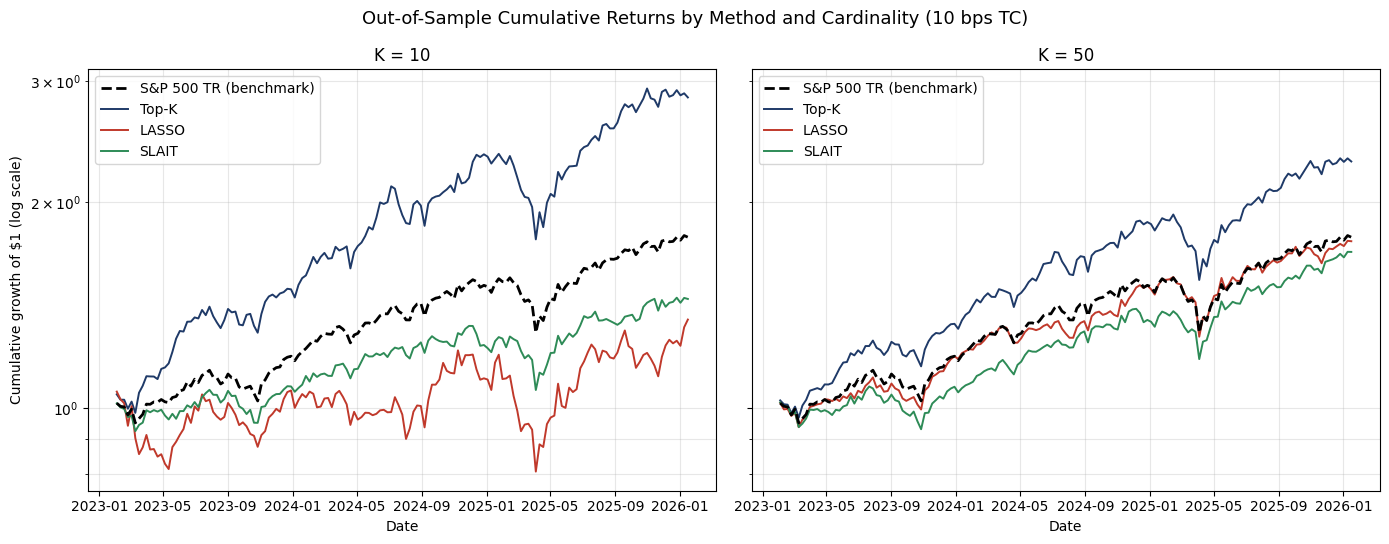

Final cumulative growth of $1 (out-of-sample, 10 bps TC):
  Benchmark: 1.776
  K=10:
    Top-K   : 2.841
    LASSO   : 1.346
    SLAIT   : 1.443
  K=50:
    Top-K   : 2.290
    LASSO   : 1.752
    SLAIT   : 1.690


In [14]:
# Visualization 1: OOS cumulative returns, two panels (K=10, K=50)
method_colors = {'topk': '#1f3a68', 'lasso': '#c0392b', 'slait': '#2e8b57'}
method_labels = {'topk': 'Top-K', 'lasso': 'LASSO', 'slait': 'SLAIT'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)

for panel_idx, K in enumerate([10, 50]):
    ax = axes[panel_idx]

    bench_cum = (1 + index_returns_oos).cumprod()
    ax.plot(bench_cum.index, bench_cum.values, color='#000000', linewidth=2.0,
            linestyle='--', label='S&P 500 TR (benchmark)', zorder=10)

    for method in ['topk', 'lasso', 'slait']:
        key = (method, K)
        if key not in results_oos or len(results_oos[key]['turnover']) == 0:
            continue
        net = apply_transaction_costs(results_oos[key]['gross'],
                                       results_oos[key]['turnover'], MAIN_TC_BPS)
        port_cum = (1 + net).cumprod()
        ax.plot(port_cum.index, port_cum.values, color=method_colors[method],
                linewidth=1.4, label=method_labels[method])

    ax.set_yscale('log')
    ax.set_title(f'K = {K}')
    ax.set_xlabel('Date')
    if panel_idx == 0:
        ax.set_ylabel('Cumulative growth of $1 (log scale)')
    ax.grid(True, alpha=0.3, which='both')
    ax.legend(loc='upper left')

fig.suptitle('Out-of-Sample Cumulative Returns by Method and Cardinality (10 bps TC)', fontsize=13)
plt.tight_layout()
plt.show()

# Final cumulative values
print("Final cumulative growth of $1 (out-of-sample, 10 bps TC):")
print(f"  Benchmark: {(1 + index_returns_oos).prod():.3f}")
for K in [10, 50]:
    print(f"  K={K}:")
    for method in ['topk', 'lasso', 'slait']:
        key = (method, K)
        if key not in results_oos or len(results_oos[key]['turnover']) == 0:
            continue
        net = apply_transaction_costs(results_oos[key]['gross'],
                                       results_oos[key]['turnover'], MAIN_TC_BPS)
        print(f"    {method_labels[method]:8s}: {(1 + net).prod():.3f}")

**Observations.** The out-of-sample period confirms the in-sample patterns and sharpens them. At K=10, top-K (blue) ends 60% above the benchmark (2.84 versus 1.78), driven by its concentration in the mega-cap names that led the 2023-2024 rally. SLAIT (green) tracks the benchmark most closely of the three, consistent with its lowest tracking error at this cardinality (7.18%). LASSO (red) is the weakest, dropping to 0.7 in early 2025 and ending at only 1.35, reflecting the poor diversification of its roughly seven effective holdings.

At K=50 the three methods converge tightly around the benchmark. LASSO recovers fully, ending at 1.75 against the benchmark's 1.78 and overlaying it for much of the period. SLAIT ends slightly below at 1.69, and top-K again drifts above at 2.29 because of its persistent mega-cap overweight.

As in-sample, top-K's outperformance is not evidence of superior tracking — it carries the highest tracking error of all methods and simply deviates from the index in a direction that happened to be favorable over this rally-dominated window. The purpose of an index tracker is to replicate the benchmark, not beat it; by that standard SLAIT at K=10 and the convergence of all methods at K=50 are the meaningful results. The close match of in-sample and out-of-sample tracking errors confirms that the methodology generalizes rather than overfitting the calibration period.

**Transaction-Cost Sensitivity**

This figure shows how net annualized return responds to rising transaction costs, at the two shared cardinality levels. The slope of each line is what matters: a steep decline indicates a method whose returns are eroded quickly by trading costs, which is the practical consequence of high turnover. Because top-K rebalances little while LASSO and SLAIT rebalance aggressively, the lines should fan out as cost increases. The benchmark, which incurs no trading cost in this framework, is shown as a flat reference.

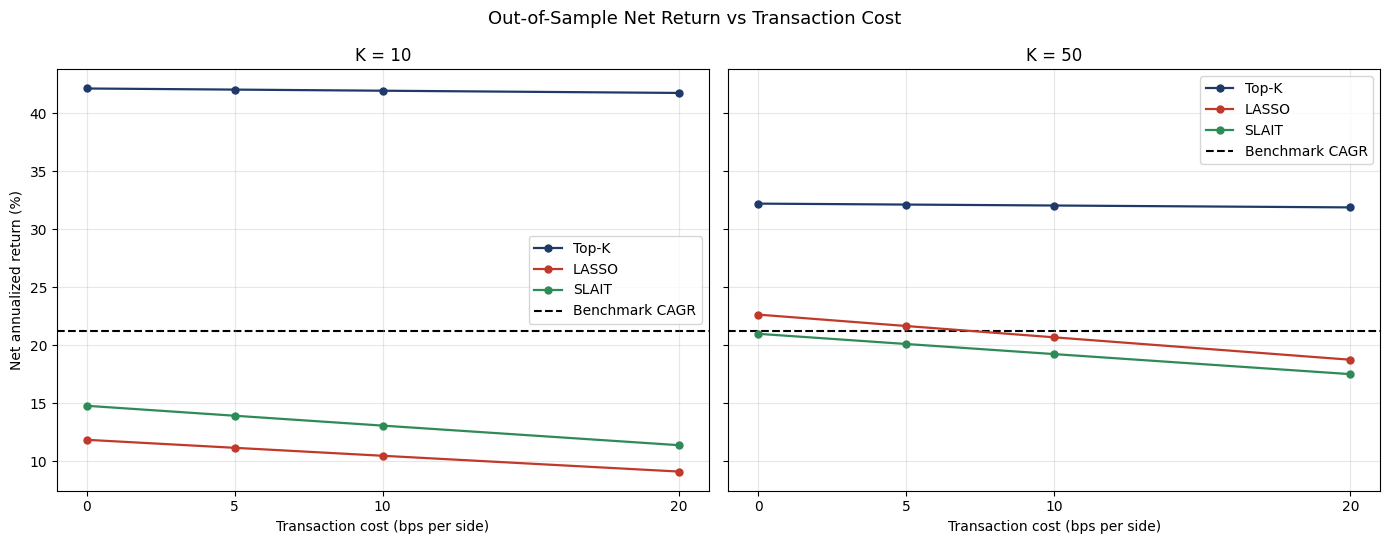

Net CAGR erosion from 0 to 20 bps:
method    K  CAGR@0bps  CAGR@20bps    drop
topk     10     42.14%      41.75%   0.38pp
lasso    10     11.86%       9.12%   2.74pp
slait    10     14.79%      11.40%   3.40pp
topk     50     32.22%      31.89%   0.33pp
lasso    50     22.65%      18.76%   3.89pp
slait    50     21.00%      17.52%   3.48pp


In [15]:
# Visualization 2: net CAGR vs transaction cost, two panels (K=10, K=50)
method_colors = {'topk': '#1f3a68', 'lasso': '#c0392b', 'slait': '#2e8b57'}
method_labels = {'topk': 'Top-K', 'lasso': 'LASSO', 'slait': 'SLAIT'}

bench_cagr = compute_performance_metrics(index_returns_oos, index_returns_oos)['ann_return']

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)

for panel_idx, K in enumerate([10, 50]):
    ax = axes[panel_idx]

    for method in ['topk', 'lasso', 'slait']:
        sub = performance_oos[(performance_oos['method'] == method) &
                              (performance_oos['K'] == K)].sort_values('tc_bps')
        if len(sub) == 0:
            continue
        ax.plot(sub['tc_bps'], sub['CAGR'] * 100, marker='o', markersize=5,
                color=method_colors[method], linewidth=1.6, label=method_labels[method])

    ax.axhline(bench_cagr * 100, color='#000000', linestyle='--', linewidth=1.5,
               label='Benchmark CAGR', zorder=1)
    ax.set_title(f'K = {K}')
    ax.set_xlabel('Transaction cost (bps per side)')
    ax.set_xticks(TC_BPS_VALUES)
    if panel_idx == 0:
        ax.set_ylabel('Net annualized return (%)')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best')

fig.suptitle('Out-of-Sample Net Return vs Transaction Cost', fontsize=13)
plt.tight_layout()
plt.show()

# Print the CAGR decline from 0 to 20 bps for each method/K
print("Net CAGR erosion from 0 to 20 bps:")
print(f"{'method':<6s} {'K':>4s} {'CAGR@0bps':>10s} {'CAGR@20bps':>11s} {'drop':>7s}")
for K in [10, 50]:
    for method in ['topk', 'lasso', 'slait']:
        sub = performance_oos[(performance_oos['method'] == method) &
                              (performance_oos['K'] == K)]
        if len(sub) == 0:
            continue
        c0 = sub[sub['tc_bps'] == 0]['CAGR'].values[0]
        c20 = sub[sub['tc_bps'] == 20]['CAGR'].values[0]
        print(f"{method:<6s} {K:>4d} {c0*100:>9.2f}% {c20*100:>10.2f}% {(c0-c20)*100:>6.2f}pp")

**Observations.** The slopes of the lines reveal the practical cost of turnover. Top-K is almost flat: raising the transaction cost from 0 to 20 bps reduces its net return by only about 0.35 percentage points, because it rebalances little (turnover near 90%). LASSO and SLAIT decline roughly ten times faster, losing between 2.7 and 3.9 percentage points over the same range, a direct consequence of their turnover of around 1500%.

The K=50 panel contains the most important result for practical use. At zero cost, LASSO and SLAIT sit at or above the benchmark (22.65% and 21.00% versus 21.24%). But as cost rises, both decline and cross below the benchmark: LASSO falls from 22.65% at 0 bps to 18.76% at 20 bps, dropping under the benchmark at roughly 8 bps. The apparent advantage of the optimizers at zero cost is therefore an artifact of ignoring trading frictions — at realistic cost levels it disappears. Top-K, by contrast, holds its level across the entire cost range.

This is the core practical finding of the project: when transaction costs are accounted for, the high-turnover optimizers lose much of their edge, and a simple, stable market-cap rule becomes competitive on a net-of-cost basis despite its higher tracking error. Tracking accuracy and net return respond to different forces, and a method that looks strong on one axis can be weak on the other.

**In-Sample versus Out-of-Sample Tracking Error**

A walk-forward strategy is only credible if its performance carries over to data not used in calibration. This figure compares annualized tracking error in-sample and out-of-sample for each method and cardinality, at the main cost of 10 bps. Points close to the diagonal indicate that tracking quality generalizes; points far above it would signal overfitting, where in-sample tracking was much tighter than what the method achieves on new data. The comparison covers the cardinalities shared between the two periods.

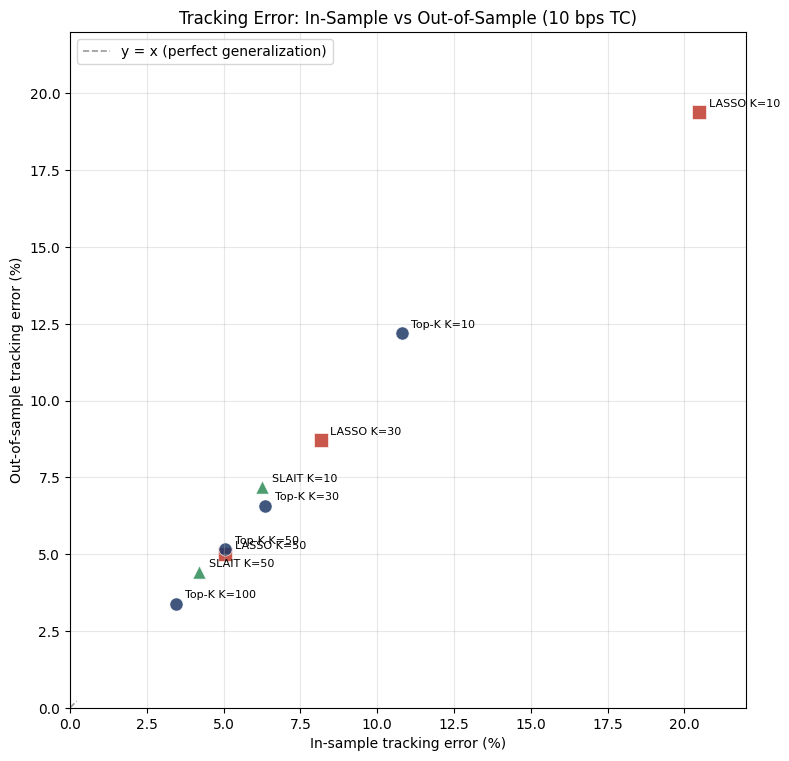

Tracking error generalization (10 bps TC):
method    K    TE_IS   TE_OOS    diff
lasso    10   20.47%   19.38%  -1.09pp
lasso    30    8.16%    8.71%  +0.55pp
lasso    50    5.06%    5.00%  -0.06pp
slait    10    6.25%    7.18%  +0.93pp
slait    50    4.20%    4.41%  +0.21pp
topk     10   10.79%   12.19%  +1.40pp
topk     30    6.35%    6.58%  +0.23pp
topk     50    5.05%    5.17%  +0.12pp
topk    100    3.44%    3.39%  -0.05pp


In [16]:
# Visualization 3: IS vs OOS tracking error scatter
method_colors = {'topk': '#1f3a68', 'lasso': '#c0392b', 'slait': '#2e8b57'}
method_labels = {'topk': 'Top-K', 'lasso': 'LASSO', 'slait': 'SLAIT'}
method_markers = {'topk': 'o', 'lasso': 's', 'slait': '^'}

# Build IS TE lookup from performance_is (which has no tc column; it was run at 10 bps)
is_te = {}
for _, r in performance_is.iterrows():
    if r['Status'] == 'ok':
        is_te[(r['method'], int(r['K']))] = r['TE_ann']

# OOS TE at main cost
oos_main = performance_oos[performance_oos['tc_bps'] == MAIN_TC_BPS]
oos_te = {(r['method'], int(r['K'])): r['TE_ann'] for _, r in oos_main.iterrows()}

fig, ax = plt.subplots(figsize=(8, 8))

# Diagonal y = x
lims = [0, 0.22]
ax.plot(lims, lims, color='#999999', linestyle='--', linewidth=1.2, label='y = x (perfect generalization)')

for (method, K) in sorted(set(is_te) & set(oos_te), key=lambda x: (x[0], x[1])):
    x = is_te[(method, K)] * 100
    y = oos_te[(method, K)] * 100
    ax.scatter(x, y, color=method_colors[method], marker=method_markers[method],
               s=90, alpha=0.85, edgecolors='white', linewidth=0.5)
    ax.annotate(f'{method_labels[method]} K={K}', (x, y),
                textcoords='offset points', xytext=(7, 4), fontsize=8)

ax.set_xlim(lims[0]*100, lims[1]*100)
ax.set_ylim(lims[0]*100, lims[1]*100)
ax.set_xlabel('In-sample tracking error (%)')
ax.set_ylabel('Out-of-sample tracking error (%)')
ax.set_title('Tracking Error: In-Sample vs Out-of-Sample (10 bps TC)')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left')
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

# Print the IS/OOS comparison
print("Tracking error generalization (10 bps TC):")
print(f"{'method':<6s} {'K':>4s} {'TE_IS':>8s} {'TE_OOS':>8s} {'diff':>7s}")
for (method, K) in sorted(set(is_te) & set(oos_te), key=lambda x: (x[0], x[1])):
    te_i = is_te[(method, K)]
    te_o = oos_te[(method, K)]
    print(f"{method:<6s} {K:>4d} {te_i*100:>7.2f}% {te_o*100:>7.2f}% {(te_o-te_i)*100:>+6.2f}pp")

**Observations.** Every method-cardinality combination lies close to the diagonal, meaning out-of-sample tracking error nearly matches the in-sample value. The largest deviations are top-K at K=10 (+1.40 pp) and LASSO at K=10 (−1.09 pp), and even these are modest; most combinations differ by less than half a percentage point between the two periods. This is strong evidence that the walk-forward methodology generalizes rather than overfitting the calibration window — the rolling refit adapts to each new period, so tracking quality is preserved even though the out-of-sample regime (the 2023 banking stress and the 2023-2024 rally) differs markedly from the in-sample years.

The deviations are mostly slightly positive, indicating that out-of-sample tracking error is marginally higher than in-sample. This is the expected direction: in-sample figures are mildly optimistic because the methodology was tuned against them. What matters is that the gap is small — fractions of a percentage point — rather than the large degradation that would indicate overfitting. The ordering of methods is also preserved: SLAIT remains the tightest tracker at each shared cardinality in both periods, confirming that its advantage is structural and not a calibration artifact.

**Annualized Turnover by Method**

This figure makes the turnover gap explicit. It shows annualized portfolio turnover for each method and cardinality out-of-sample. Turnover is the sum of absolute weight changes per rebalance, annualized — a value of 100% means the equivalent of fully replacing the portfolio once per year. This is the quantity that drives the cost sensitivity seen earlier: methods with high turnover lose more return as transaction costs rise.

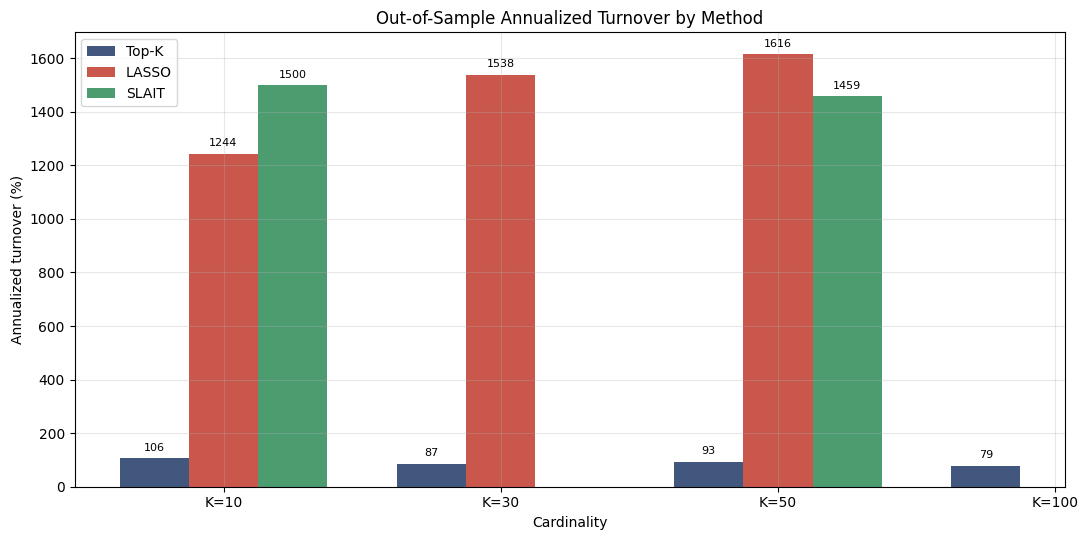

Annualized turnover (%):
    K    Top-K    LASSO    SLAIT
   10      106     1244     1500
   30       87     1538        —
   50       93     1616     1459
  100       79        —        —


In [17]:
# Visualization 4: annualized turnover by method and K
method_colors = {'topk': '#1f3a68', 'lasso': '#c0392b', 'slait': '#2e8b57'}
method_labels = {'topk': 'Top-K', 'lasso': 'LASSO', 'slait': 'SLAIT'}

main = performance_oos[performance_oos['tc_bps'] == MAIN_TC_BPS]

all_K = [10, 30, 50, 100]
x = np.arange(len(all_K))
bar_width = 0.25

fig, ax = plt.subplots(figsize=(11, 5.5))

for i, method in enumerate(['topk', 'lasso', 'slait']):
    heights = []
    for K in all_K:
        row = main[(main['method'] == method) & (main['K'] == K)]
        heights.append(row['Turnover_ann'].values[0] * 100 if len(row) else np.nan)
    offsets = x + (i - 1) * bar_width
    ax.bar(offsets, heights, bar_width, label=method_labels[method],
           color=method_colors[method], alpha=0.85)
    for off, h in zip(offsets, heights):
        if not np.isnan(h):
            ax.text(off, h + 20, f'{h:.0f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels([f'K={K}' for K in all_K])
ax.set_xlabel('Cardinality')
ax.set_ylabel('Annualized turnover (%)')
ax.set_title('Out-of-Sample Annualized Turnover by Method')
ax.grid(True, alpha=0.3, axis='y')
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

print("Annualized turnover (%):")
print(f"{'K':>5s} {'Top-K':>8s} {'LASSO':>8s} {'SLAIT':>8s}")
for K in all_K:
    vals = {}
    for method in ['topk', 'lasso', 'slait']:
        row = main[(main['method'] == method) & (main['K'] == K)]
        vals[method] = f"{row['Turnover_ann'].values[0]*100:.0f}" if len(row) else "—"
    print(f"{K:>5d} {vals['topk']:>8s} {vals['lasso']:>8s} {vals['slait']:>8s}")

**Observations.** The turnover gap is an order of magnitude. Top-K rebalances modestly — between 79% and 106% annualized, roughly equivalent to replacing the portfolio once per year — because its mega-cap composition is stable as market capitalizations evolve slowly. LASSO and SLAIT turn over between 1244% and 1616%, meaning they replace the equivalent of their entire portfolio more than a dozen times per year. This reflects the fact that both optimizers re-select their holdings from scratch at each rebalance based on the most recent lookback window, whereas top-K simply re-ranks the same large constituents.

This single chart explains the cost-sensitivity result. At 10 bps per side, turnover of 1500% costs roughly 1.5 percentage points of annual return, and at 20 bps it costs about 3 percentage points — exactly the erosion observed earlier. Top-K's stable composition makes it nearly immune to transaction costs, while the optimizers carry a structural cost burden that grows with the assumed friction. In a setting with higher trading costs or lower liquidity, this would be decisive.

**Risk-Return Positioning**

The final figure places every portfolio in risk-return space: annualized volatility on the horizontal axis, annualized net return on the vertical, at the main cost of 10 bps. The benchmark is marked as a reference point. This view summarizes the trade-offs across methods and cardinalities in a single picture — portfolios up and to the left are more attractive on a risk-adjusted basis. Marker shape encodes the method and size encodes cardinality, so the effect of adding assets is visible as a trajectory.

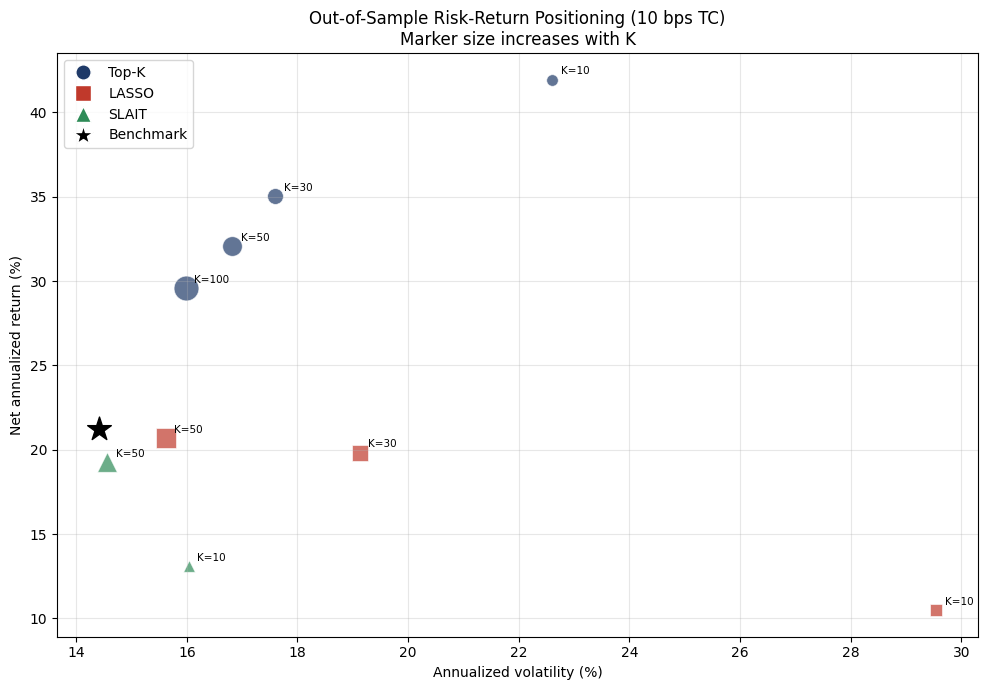

Risk-return summary (10 bps TC):
method    K      Vol     CAGR  Sharpe
topk     10   22.60%   41.95%   1.856
topk     30   17.60%   35.03%   1.991
topk     50   16.82%   32.05%   1.906
topk    100   15.99%   29.57%   1.850
lasso    10   29.55%   10.49%   0.355
lasso    30   19.13%   19.82%   1.036
lasso    50   15.63%   20.69%   1.324
slait    10   16.03%   13.08%   0.816
slait    50   14.56%   19.25%   1.321
bench     —   14.41%   21.24%   1.474


In [18]:
# Visualization 5: risk-return scatter at main TC
method_colors = {'topk': '#1f3a68', 'lasso': '#c0392b', 'slait': '#2e8b57'}
method_labels = {'topk': 'Top-K', 'lasso': 'LASSO', 'slait': 'SLAIT'}
method_markers = {'topk': 'o', 'lasso': 's', 'slait': '^'}
K_sizes = {10: 70, 30: 130, 50: 200, 100: 320}

main = performance_oos[performance_oos['tc_bps'] == MAIN_TC_BPS]

fig, ax = plt.subplots(figsize=(10, 7))

for _, r in main.iterrows():
    method, K = r['method'], int(r['K'])
    ax.scatter(r['Vol_ann']*100, r['CAGR']*100,
               color=method_colors[method], marker=method_markers[method],
               s=K_sizes.get(K, 100), alpha=0.7, edgecolors='white', linewidth=0.6)
    ax.annotate(f'K={K}', (r['Vol_ann']*100, r['CAGR']*100),
                textcoords='offset points', xytext=(6, 4), fontsize=7.5)

# Benchmark marker
bm = compute_performance_metrics(index_returns_oos, index_returns_oos)
ax.scatter(bm['ann_volatility']*100, bm['ann_return']*100,
           color='#000000', marker='*', s=320, label='Benchmark', zorder=10)

# Method legend (proxy handles)
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker=method_markers[m], color='w',
           markerfacecolor=method_colors[m], markersize=11, label=method_labels[m])
    for m in ['topk', 'lasso', 'slait']
]
legend_elements.append(Line2D([0], [0], marker='*', color='w',
                              markerfacecolor='#000000', markersize=15, label='Benchmark'))
ax.legend(handles=legend_elements, loc='upper left')

ax.set_xlabel('Annualized volatility (%)')
ax.set_ylabel('Net annualized return (%)')
ax.set_title('Out-of-Sample Risk-Return Positioning (10 bps TC)\nMarker size increases with K')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Risk-return summary (10 bps TC):")
print(f"{'method':<6s} {'K':>4s} {'Vol':>8s} {'CAGR':>8s} {'Sharpe':>7s}")
for _, r in main.iterrows():
    print(f"{r['method']:<6s} {int(r['K']):>4d} {r['Vol_ann']*100:>7.2f}% "
          f"{r['CAGR']*100:>7.2f}% {r['Sharpe']:>7.3f}")
print(f"{'bench':<6s} {'—':>4s} {bm['ann_volatility']*100:>7.2f}% "
      f"{bm['ann_return']*100:>7.2f}% {bm['sharpe']:>7.3f}")

**Observations.** The risk-return view consolidates the project's findings. Top-K (blue circles) sits high and to the right: it delivers the strongest net returns (30-42%) but at elevated volatility, especially at K=10 (22.6%). As K grows, its markers move left toward the benchmark's volatility while staying above it in return — the signature of its mega-cap tilt, which paid off in this rally-driven period. SLAIT (green triangles) clusters closest to the benchmark in volatility; SLAIT at K=50 even has slightly lower volatility (14.56%) than the benchmark (14.41%), indicating faithful replication of the index risk profile. LASSO (red squares) is the most dispersed: at K=10 it occupies the worst corner, with the highest volatility (29.55%) and lowest return (10.49%), but it converges rapidly toward the benchmark as K increases.

The dominant visual pattern is convergence: for every method, larger K moves the portfolio closer to the benchmark star. This is the central principle of index tracking made visible — adding assets tightens the replication of the index's risk and return. Top-K's high Sharpe ratios (up to 1.99 versus the benchmark's 1.47) again reflect a favorable realization of its deviation rather than tracking skill; the portfolios that genuinely sit near the benchmark in both dimensions — SLAIT and LASSO at K=50 — are the ones fulfilling the tracking objective.

#Data Saving

The out-of-sample evaluation is complete. The gross returns, per-rebalance turnover, and weights were already persisted during the backtest run; the performance table across all cost levels was saved alongside the sensitivity analysis. This final step records a manifest that documents the out-of-sample artifacts and configuration, mirroring the manifest produced in Notebook 02, so that the full project leaves a consistent and self-describing set of files.

In [19]:
# Verify OOS artifacts and write a manifest
expected_artifacts = {
    'backtest_gross_oos.parquet':    'OOS weekly gross portfolio returns (pre-cost), wide format',
    'backtest_turnover_oos.parquet': 'OOS per-rebalance turnover, wide format',
    'backtest_weights_oos.parquet':  'OOS rebalance weights, MultiIndex columns (method, K, ticker)',
    'performance_oos.parquet':       'OOS performance metrics across all (method, K, tc_bps) combinations',
}

print("Verifying OOS artifacts in CACHE_DIR:\n")
manifest = {
    'notebook': '03_evaluation',
    'created': pd.Timestamp.now().isoformat(),
    'config': {
        'lookback_weeks': int(LOOKBACK_WEEKS),
        'rebalance_freq_weeks': int(REBALANCE_FREQ_WEEKS),
        'k_values_fast': list(K_VALUES_FAST),
        'k_values_slait': list(K_VALUES_SLAIT),
        'tc_bps_values': list(TC_BPS_VALUES),
        'main_tc_bps': int(MAIN_TC_BPS),
        'n_oos_rebalances': int(len(rebalance_dates_oos)),
        'oos_period_start': str(rebalance_dates_oos[0].date()),
        'oos_period_end': str(rebalance_dates_oos[-1].date()),
    },
    'artifacts': {},
}

all_ok = True
for fname, description in expected_artifacts.items():
    fpath = os.path.join(CACHE_DIR, fname)
    if os.path.exists(fpath):
        size_kb = os.path.getsize(fpath) / 1024
        try:
            df = pd.read_parquet(fpath)
            shape = df.shape
            status = 'OK'
        except Exception as e:
            shape = None
            status = f'READ ERROR'
            all_ok = False
        print(f"  {fname:<34s} {status:<6s} shape={shape}, {size_kb:.1f} KB")
        manifest['artifacts'][fname] = {
            'description': description,
            'shape': list(shape) if shape else None,
            'size_kb': round(size_kb, 1),
        }
    else:
        print(f"  {fname:<34s} MISSING")
        all_ok = False
        manifest['artifacts'][fname] = {'description': description, 'status': 'MISSING'}

manifest_path = os.path.join(CACHE_DIR, 'manifest_evaluation.json')
with open(manifest_path, 'w') as f:
    json.dump(manifest, f, indent=2)

print(f"\nManifest saved: {manifest_path}")
print(f"Overall status: {'ALL ARTIFACTS OK' if all_ok else 'SOME ARTIFACTS MISSING'}")

Verifying OOS artifacts in CACHE_DIR:

  backtest_gross_oos.parquet         OK     shape=(155, 10), 20.5 KB
  backtest_turnover_oos.parquet      OK     shape=(39, 10), 10.2 KB
  backtest_weights_oos.parquet       OK     shape=(39, 4770), 3208.1 KB
  performance_oos.parquet            OK     shape=(36, 10), 8.0 KB

Manifest saved: /content/drive/MyDrive/ml_finance_project_index_tracking/cache_modeling/manifest_evaluation.json
Overall status: ALL ARTIFACTS OK
